# Name :  Mayuri Mahesh Gade
## Assignement No 13

## To apply Decision Tree Classification to a given dataset, analyse the performance of the model, and interpret the results.

In [274]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix,f1_score, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.preprocessing import label_binarize

In [276]:
data=pd.read_csv(r"F:\download folder\heart_disease.csv")
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,FALSE,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,FALSE,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,FALSE,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,FALSE,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,TRUE,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,0,False,normal,120,FALSE,1.5,upsloping,fixed defect,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,TRUE,3.0,flat,fixed defect,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,TRUE,2.5,downsloping,normal,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,NaN,downsloping,reversable defect,4


In [278]:
data.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [280]:
data['sex'] = data['sex'].map({'Male': 1, 'Female': 0})
data['cp'] = data['cp'].map({
    'typical angina': 1,
    'atypical angina': 2,
    'non-anginal': 3,
    'asymptomatic': 4
    })


In [282]:
data['restecg'] = data['restecg'].map({'normal': 0, 'lv hypertrophy': 1, 'st-t abnormality': 2})
data['slope'] = data['slope'].map({'upsloping': 1, 'flat': 0, 'downsloping': 2})
data['thal'] = data['thal'].map({'normal': 1, 'fixed defect': 2, 'reversable defect': 3})

In [284]:
data['exang'] = data['exang'].replace({'TRUE': 1, 'FALSE': 0, 'TURE': 1})

C:\Users\Aniket\AppData\Local\Temp\ipykernel_10940\2749244516.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['exang'] = data['exang'].replace({'TRUE': 1, 'FALSE': 0, 'TURE': 1})


In [286]:
X = data.drop(columns=['num'])  # Features
y = data['num'] 

In [288]:
y_bin = label_binarize(y, classes=[0, 1, 2, 3, 4])  # Adjust classes based on your dataset
n_classes = y_bin.shape[1]

In [290]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [292]:
# Initialize the model
model = DecisionTreeClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [294]:
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

In [296]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[63 14  5  5  2]
 [14 21  7  6  0]
 [ 6  4  5  5  2]
 [ 3 10  1  2  1]
 [ 0  3  3  0  0]]
              precision    recall  f1-score   support

           0       0.73      0.71      0.72        89
           1       0.40      0.44      0.42        48
           2       0.24      0.23      0.23        22
           3       0.11      0.12      0.11        17
           4       0.00      0.00      0.00         6

    accuracy                           0.50       182
   macro avg       0.30      0.30      0.30       182
weighted avg       0.50      0.50      0.50       182



In [298]:
f1 = f1_score(y_test, y_pred, average='macro')
print(f"F1 Score: {f1}")


F1 Score: 0.2973687707641196


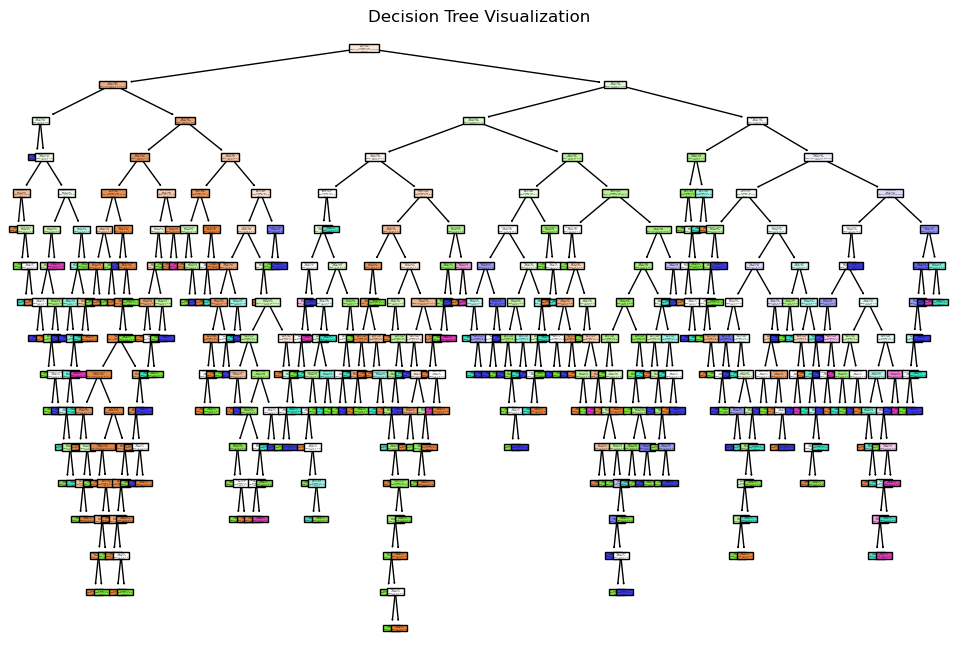

In [300]:
plt.figure(figsize=(12,8))
tree.plot_tree(model, filled=True, feature_names=X.columns, class_names=y.unique().astype(str))
plt.title("Decision Tree Visualization")
plt.show()